# Modeling — Task 2

**Objective.** Build, train and compare classification models for fraud detection on two severely imbalanced datasets, then select one with a justified trade-off between performance and interpretability.

**Protocol** (identical for both datasets, implemented in [`src/modeling.py`](../src/modeling.py) and [`src/evaluation.py`](../src/evaluation.py)):

1. Separate features from target, then a **stratified 80/20 split** so both halves keep the real fraud rate.
2. Wrap scaling + encoding + **SMOTE** + estimator in a single `imblearn` pipeline. SMOTE runs on `fit` only — never on `predict` — so every CV fold resamples its own training portion and the test set stays at production prevalence.
3. **Baseline:** Logistic Regression. **Ensemble:** XGBoost, with a small grid search on `n_estimators` / `max_depth` / `learning_rate` scored by AUC-PR.
4. **5-fold stratified CV** on the training half for mean ± std.
5. Pick the decision threshold from **out-of-fold training** probabilities, then score once on the held-out test set.

**Metrics.** AUC-PR (primary), F1, precision, recall, confusion matrix. Accuracy is excluded: predicting "legitimate" every time scores 90.6% / 99.83% and catches no fraud.

> The exhaustive grid searches live in [`scripts/train_models.py`](../scripts/train_models.py) (~1 h). This notebook narrates the protocol using the winning hyperparameters that run recorded in `reports/task2_tuning_*.csv`, so it executes in minutes and reproduces the same numbers.

In [1]:
import sys
from pathlib import Path

# Make the project root importable so `from src import ...` resolves.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

from src import config
config.ensure_dirs()
FIG = config.FIGURES_DIR


In [2]:
import joblib
from src import modeling as md, evaluation as ev

CV_FOLDS = 5

def best_params(dataset, model_key, fallback):
    """Winning hyperparameters from scripts/train_models.py.

    Read from the recorded tuning table when present so the notebook
    tracks the real search; `fallback` keeps it runnable standalone.
    """
    path = config.REPORTS_DIR / f'task2_tuning_{dataset}.csv'
    if not path.exists():
        return fallback
    tbl = pd.read_csv(path)
    top = tbl[(tbl['model'] == model_key) & (tbl['rank_test_score'] == 1)]
    if top.empty:
        return fallback
    row = top.iloc[0]
    out = {}
    for col in [c for c in tbl.columns if c.startswith('param_clf__')]:
        val = row[col]
        if pd.notna(val):
            out[col.replace('param_clf__', '')] = val
    return out or fallback

print('helpers ready')

helpers ready


## 1. Fraud_Data — features and target

Features are the Task-1 engineered columns plus the geolocated `country`. `country` has 182 levels, so the encoder folds levels below 1% frequency into one *infrequent* column instead of emitting a long tail of near-empty dummies.

In [3]:
fraud = pd.read_csv(config.FRAUD_FEATURES)
feature_cols = md.FRAUD_NUMERIC_COLS + md.FRAUD_CATEGORICAL_COLS
X, y = md.split_features_target(fraud, config.FRAUD_TARGET, feature_cols)
for c in md.FRAUD_CATEGORICAL_COLS:
    X[c] = X[c].astype(str)
print('X:', X.shape, '| target:', config.FRAUD_TARGET)
print(f'fraud rate: {y.mean():.4%}')
X.head()

X: (151112, 13) | target: class
fraud rate: 9.3646%


,purchase_value,age,hour_of_day,day_of_week,time_since_signup,user_transaction_count,device_transaction_count,device_user_count,device_velocity_24h,source,browser,sex,country
0,34,39,2,5,1251.856111,1,1,1,1,SEO,Chrome,M,Japan
1,16,53,1,0,4.984444,1,1,1,1,Ads,Chrome,F,United States
2,15,53,18,3,0.000278,1,12,12,11,SEO,Opera,M,United States
3,44,41,13,0,136.690278,1,1,1,1,SEO,Safari,M,Unknown
4,39,45,18,2,1211.516944,1,1,1,1,Ads,Safari,M,United States


## 2. Stratified train/test split

Stratifying matters most on the credit-card set (473 frauds total) but we apply it to both so the reported metrics are comparable to production prevalence.

In [4]:
X_train, X_test, y_train, y_test = md.stratified_split(X, y, test_size=0.2)
print(f'train {X_train.shape[0]:,} rows, fraud {y_train.mean():.4%}')
print(f'test  {X_test.shape[0]:,} rows, fraud {y_test.mean():.4%}')
print('\nSplit preserved the class ratio — no resampling has happened yet.')

train 120,889 rows, fraud 9.3648%
test  30,223 rows, fraud 9.3637%

Split preserved the class ratio — no resampling has happened yet.


## 3. Baseline — Logistic Regression + SMOTE

A linear model is the right baseline here: coefficients are directly readable (each is a log-odds contribution), it trains in seconds, and it sets the bar any ensemble must clear to justify its opacity.

In [5]:
lr_params = best_params('fraud', 'logreg_smote', {'C': 1.0})
lr = md.fraud_pipeline(md.build_logistic_regression(C=float(lr_params['C'])))
lr.fit(X_train, y_train)
lr_scores = ev.predict_proba_positive(lr, X_test)
print('tuned C =', lr_params['C'])
pd.Series(ev.classification_metrics(y_test, lr_scores)).to_frame('logreg @0.50').round(4)

tuned C = 0.1


,logreg @0.50
auc_pr,0.6750
f1,0.6210
precision,0.5849
recall,0.6618
roc_auc,0.8389
threshold,0.5000
tn,26064.0000
fp,1329.0000
fn,957.0000
tp,1873.0000


### Why the default 0.50 threshold is wrong after SMOTE

SMOTE balances the training set, so the model's scores are calibrated to a 50/50 world, not a 9% one — 0.50 therefore over-predicts fraud. We choose the threshold from **out-of-fold training** probabilities (`ev.select_threshold`), which never touches the test set.

In [6]:
lr_thr, lr_oof_f1 = ev.select_threshold(lr, X_train, y_train, cv=3)
print(f'threshold from out-of-fold train scores: {lr_thr:.4f} (out-of-fold F1 {lr_oof_f1:.4f})')
lr_metrics = ev.classification_metrics(y_test, lr_scores, lr_thr)
display(pd.Series(lr_metrics).to_frame('logreg @tuned').round(4))
print('\nConfusion matrix (test set):')
display(ev.confusion_frame(y_test, lr_scores, lr_thr))

threshold from out-of-fold train scores: 0.8058 (out-of-fold F1 0.6794)


,logreg @tuned
auc_pr,0.6750
f1,0.6677
precision,0.9061
recall,0.5286
roc_auc,0.8389
threshold,0.8058
tn,27238.0000
fp,155.0000
fn,1334.0000
tp,1496.0000



Confusion matrix (test set):


,predicted: legitimate,predicted: fraud
actual: legitimate,27238,155
actual: fraud,1334,1496


### Baseline interpretability

The coefficients are the reason to keep a linear model in the running: each one is an auditable statement about the direction and size of a feature's effect.

,coefficient (log-odds)
num__device_transaction_count,1.391
num__device_user_count,1.391
cat__country_United States,0.326
cat__browser_Opera,-0.302
num__device_velocity_24h,0.268
cat__country_France,-0.264
cat__country_infrequent_sklearn,0.243
cat__country_Brazil,-0.243
cat__country_Australia,-0.232
cat__country_Unknown,0.228


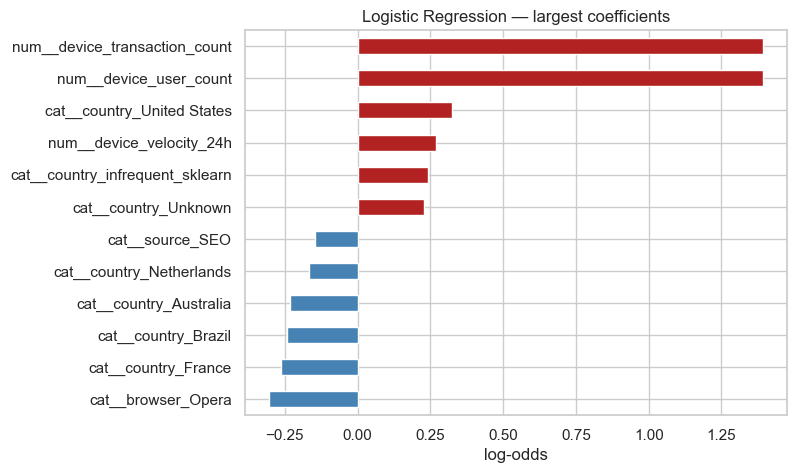

In [7]:
names = lr.named_steps['preprocess'].get_feature_names_out()
coefs = pd.Series(lr.named_steps['clf'].coef_[0], index=names)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)
display(top.to_frame('coefficient (log-odds)').round(3))
fig, ax = plt.subplots(figsize=(7, 5))
top.sort_values().plot.barh(ax=ax, color=np.where(top.sort_values() > 0, 'firebrick', 'steelblue'))
ax.set(title='Logistic Regression — largest coefficients', xlabel='log-odds')
plt.savefig(FIG / 'fraud_logreg_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Ensemble — XGBoost

Gradient-boosted trees capture the interactions a linear model cannot — e.g. *low `time_since_signup` **and** high `device_user_count`* is far more suspicious than either alone.

Two imbalance strategies are compared on identical splits:

| Variant | Imbalance handling |
|---|---|
| `xgb_smote` | SMOTE synthesises minority rows inside each fold |
| `xgb_weighted` | `scale_pos_weight = n_neg/n_pos` reweights the gradient |

Weighting is cheaper (no synthetic rows) and, for trees, usually at least as good — worth measuring rather than assuming.

In [8]:
xgb_grid_fallback = {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05}
xgb_p = best_params('fraud', 'xgb_smote', xgb_grid_fallback)
xgb_p = {k: (int(v) if k != 'learning_rate' else float(v)) for k, v in xgb_p.items()}
print('tuned XGBoost params:', xgb_p)

xgb = md.fraud_pipeline(md.build_xgboost(**xgb_p))
xgb.fit(X_train, y_train)
xgb_scores = ev.predict_proba_positive(xgb, X_test)
xgb_thr, _ = ev.select_threshold(xgb, X_train, y_train, cv=3)
xgb_metrics = ev.classification_metrics(y_test, xgb_scores, xgb_thr)
display(pd.Series(xgb_metrics).to_frame('xgb+smote @tuned').round(4))
display(ev.confusion_frame(y_test, xgb_scores, xgb_thr))

tuned XGBoost params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 400}


,xgb+smote @tuned
auc_pr,0.7118
f1,0.6891
precision,0.9811
recall,0.5311
roc_auc,0.8391
threshold,0.4526
tn,27364.0000
fp,29.0000
fn,1327.0000
tp,1503.0000


,predicted: legitimate,predicted: fraud
actual: legitimate,27364,29
actual: fraud,1327,1503


In [9]:
# Cost-weighted variant: no SMOTE, reweighted positives instead.
spw = md.positive_class_weight(y_train)
xgb_w_p = best_params('fraud', 'xgb_weighted', xgb_grid_fallback)
xgb_w_p = {k: (int(v) if k != 'learning_rate' else float(v)) for k, v in xgb_w_p.items()}
xgb_w = md.fraud_pipeline(
    md.build_xgboost(scale_pos_weight=spw, **xgb_w_p), sampler=None)
xgb_w.fit(X_train, y_train)
xgb_w_scores = ev.predict_proba_positive(xgb_w, X_test)
xgb_w_thr, _ = ev.select_threshold(xgb_w, X_train, y_train, cv=3)
xgb_w_metrics = ev.classification_metrics(y_test, xgb_w_scores, xgb_w_thr)
print(f'scale_pos_weight = {spw:.2f}')
display(pd.Series(xgb_w_metrics).to_frame('xgb+weight @tuned').round(4))

scale_pos_weight = 9.68


,xgb+weight @tuned
auc_pr,0.7141
f1,0.6900
precision,0.9993
recall,0.5269
roc_auc,0.8387
threshold,0.8956
tn,27392.0000
fp,1.0000
fn,1339.0000
tp,1491.0000


## 5. Cross-validation — 5-fold stratified

A single split can flatter or punish a model by luck. Each fold refits the **whole pipeline** (scaler, encoder, SMOTE, model), so the spread below is an honest stability estimate rather than a leakage artefact.

In [10]:
cv_rows = []
for label, pipe in [('Logistic Regression + SMOTE', lr),
                    ('XGBoost + SMOTE', xgb),
                    ('XGBoost + scale_pos_weight', xgb_w)]:
    frame = ev.cross_validate_model(pipe, X_train, y_train, cv=CV_FOLDS)
    print(f'--- {label} ---')
    display(frame.round(4))
    cv_rows.append(ev.cv_summary_row(frame, label))
fraud_cv = pd.DataFrame(cv_rows)
print('5-fold CV on the training half (mean ± std):')
fraud_cv

--- Logistic Regression + SMOTE ---


,mean,std
metric,,
auc_pr,0.6823,0.0073
f1,0.6247,0.0027
precision,0.5870,0.0065
recall,0.6676,0.0049
roc_auc,0.8437,0.0064


--- XGBoost + SMOTE ---


,mean,std
metric,,
auc_pr,0.7212,0.0061
f1,0.7009,0.0061
precision,0.9950,0.0014
recall,0.5410,0.0071
roc_auc,0.8452,0.0034


--- XGBoost + scale_pos_weight ---


,mean,std
metric,,
auc_pr,0.7226,0.0059
f1,0.6189,0.0034
precision,0.5460,0.0034
recall,0.7142,0.0059
roc_auc,0.8463,0.0041


5-fold CV on the training half (mean ± std):


,model,auc_pr,f1,precision,recall,roc_auc
0,Logistic Regression + SMOTE,0.6823 ± 0.0073,0.6247 ± 0.0027,0.5870 ± 0.0065,0.6676 ± 0.0049,0.8437 ± 0.0064
1,XGBoost + SMOTE,0.7212 ± 0.0061,0.7009 ± 0.0061,0.9950 ± 0.0014,0.5410 ± 0.0071,0.8452 ± 0.0034
2,XGBoost + scale_pos_weight,0.7226 ± 0.0059,0.6189 ± 0.0034,0.5460 ± 0.0034,0.7142 ± 0.0059,0.8463 ± 0.0041


## 6. Fraud_Data comparison

,auc_pr,f1,precision,recall,roc_auc,threshold,tn,fp,fn,tp,model
0,0.7141,0.6900,0.9993,0.5269,0.8387,0.8956,27392,1,1339,1491,XGBoost + scale_pos_weight
1,0.7118,0.6891,0.9811,0.5311,0.8391,0.4526,27364,29,1327,1503,XGBoost + SMOTE
2,0.6750,0.6677,0.9061,0.5286,0.8389,0.8058,27238,155,1334,1496,Logistic Regression + SMOTE


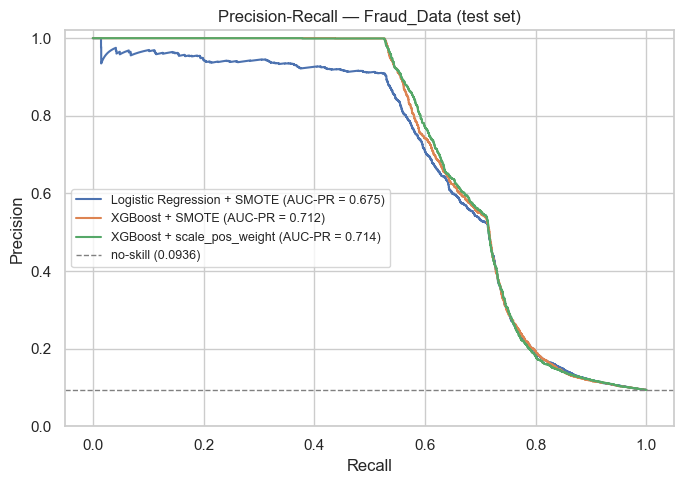

In [11]:
fraud_test = ev.comparison_table([
    {**lr_metrics, 'model': 'Logistic Regression + SMOTE'},
    {**xgb_metrics, 'model': 'XGBoost + SMOTE'},
    {**xgb_w_metrics, 'model': 'XGBoost + scale_pos_weight'},
])
display(fraud_test.round(4))
ev.plot_pr_curves(
    {'Logistic Regression + SMOTE': (y_test.to_numpy(), lr_scores),
     'XGBoost + SMOTE': (y_test.to_numpy(), xgb_scores),
     'XGBoost + scale_pos_weight': (y_test.to_numpy(), xgb_w_scores)},
    'Precision-Recall — Fraud_Data (test set)',
    FIG / 'fraud_pr_curves_nb.png')
plt.show()

## 7. creditcard — the same protocol at 0.17% fraud

The features are already anonymised PCA components, so there is no categorical encoding: the pipeline is scale → SMOTE → model. With only **473 frauds in 283,726 rows**, this is where AUC-PR earns its keep — ROC-AUC looks excellent for models that are barely usable.

In [12]:
cc = pd.read_csv(config.CREDITCARD_CLEAN)
cc_cols = md.creditcard_feature_cols(cc, config.CREDITCARD_TARGET)
Xc, yc = md.split_features_target(cc, config.CREDITCARD_TARGET, cc_cols)
Xc_train, Xc_test, yc_train, yc_test = md.stratified_split(Xc, yc, test_size=0.2)
print(f'{Xc.shape[0]:,} rows x {Xc.shape[1]} features | fraud {yc.mean():.4%}')
print(f'train frauds: {int(yc_train.sum())} | test frauds: {int(yc_test.sum())}')

283,726 rows x 30 features | fraud 0.1667%
train frauds: 378 | test frauds: 95


In [13]:
cc_lr_p = best_params('creditcard', 'logreg_smote', {'C': 1.0})
cc_lr = md.creditcard_pipeline(
    md.build_logistic_regression(C=float(cc_lr_p['C'])), cc_cols)
cc_lr.fit(Xc_train, yc_train)
cc_lr_scores = ev.predict_proba_positive(cc_lr, Xc_test)
cc_lr_thr, _ = ev.select_threshold(cc_lr, Xc_train, yc_train, cv=3)
cc_lr_metrics = ev.classification_metrics(yc_test, cc_lr_scores, cc_lr_thr)
print('Baseline at the default 0.50 vs the tuned threshold:')
display(pd.DataFrame([
    ev.classification_metrics(yc_test, cc_lr_scores, 0.5, label='logreg @0.50'),
    {**cc_lr_metrics, 'model': f'logreg @{cc_lr_thr:.3f}'},
]).set_index('model').round(4))
print('At 0.50 the baseline flags ~1,500 legitimate transactions to catch ~83 frauds —')
print('precision ~5%. Threshold choice is not cosmetic on this dataset.')

Baseline at the default 0.50 vs the tuned threshold:


,auc_pr,f1,precision,recall,roc_auc,threshold,tn,fp,fn,tp
model,,,,,,,,,,
logreg @0.50,0.6687,0.1001,0.0531,0.8737,0.9625,0.5,55170,1481,12,83
logreg @1.000,0.6687,0.8045,0.8571,0.7579,0.9625,1.0,56639,12,23,72


At 0.50 the baseline flags ~1,500 legitimate transactions to catch ~83 frauds —
precision ~5%. Threshold choice is not cosmetic on this dataset.


In [14]:
cc_xgb_p = best_params('creditcard', 'xgb_smote', xgb_grid_fallback)
cc_xgb_p = {k: (int(v) if k != 'learning_rate' else float(v)) for k, v in cc_xgb_p.items()}
cc_xgb = md.creditcard_pipeline(md.build_xgboost(**cc_xgb_p), cc_cols)
cc_xgb.fit(Xc_train, yc_train)
cc_xgb_scores = ev.predict_proba_positive(cc_xgb, Xc_test)
cc_xgb_thr, _ = ev.select_threshold(cc_xgb, Xc_train, yc_train, cv=3)
cc_xgb_metrics = ev.classification_metrics(yc_test, cc_xgb_scores, cc_xgb_thr)

cc_spw = md.positive_class_weight(yc_train)
cc_xgb_w_p = best_params('creditcard', 'xgb_weighted', xgb_grid_fallback)
cc_xgb_w_p = {k: (int(v) if k != 'learning_rate' else float(v)) for k, v in cc_xgb_w_p.items()}
cc_xgb_w = md.creditcard_pipeline(
    md.build_xgboost(scale_pos_weight=cc_spw, **cc_xgb_w_p), cc_cols, sampler=None)
cc_xgb_w.fit(Xc_train, yc_train)
cc_xgb_w_scores = ev.predict_proba_positive(cc_xgb_w, Xc_test)
cc_xgb_w_thr, _ = ev.select_threshold(cc_xgb_w, Xc_train, yc_train, cv=3)
cc_xgb_w_metrics = ev.classification_metrics(yc_test, cc_xgb_w_scores, cc_xgb_w_thr)
print(f'scale_pos_weight = {cc_spw:.1f}')
cc_test = ev.comparison_table([
    {**cc_lr_metrics, 'model': 'Logistic Regression + SMOTE'},
    {**cc_xgb_metrics, 'model': 'XGBoost + SMOTE'},
    {**cc_xgb_w_metrics, 'model': 'XGBoost + scale_pos_weight'},
])
cc_test.round(4)

scale_pos_weight = 599.5


,auc_pr,f1,precision,recall,roc_auc,threshold,tn,fp,fn,tp,model
0,0.8224,0.8639,0.9865,0.7684,0.9785,0.8510,56650,1,22,73,XGBoost + scale_pos_weight
1,0.8190,0.8383,0.9722,0.7368,0.9709,0.9607,56649,2,25,70,XGBoost + SMOTE
2,0.6687,0.8045,0.8571,0.7579,0.9625,1.0000,56639,12,23,72,Logistic Regression + SMOTE


creditcard — 5-fold CV on the training half (mean ± std):


,model,auc_pr,f1,precision,recall,roc_auc
0,Logistic Regression + SMOTE,0.7529 ± 0.0262,0.1039 ± 0.0097,0.0551 ± 0.0055,0.9073 ± 0.0337,0.9809 ± 0.0082
1,XGBoost + SMOTE,0.8486 ± 0.0314,0.8162 ± 0.0249,0.8151 ± 0.0273,0.8200 ± 0.0510,0.9780 ± 0.0053
2,XGBoost + scale_pos_weight,0.8531 ± 0.0271,0.8640 ± 0.0260,0.9092 ± 0.0369,0.8254 ± 0.0453,0.9820 ± 0.0057


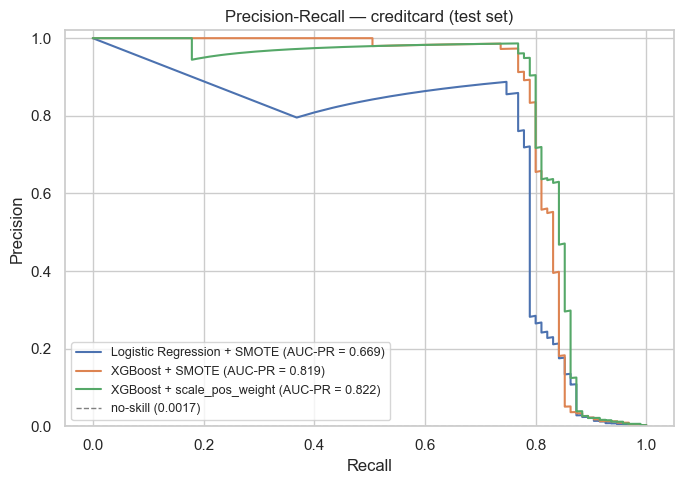

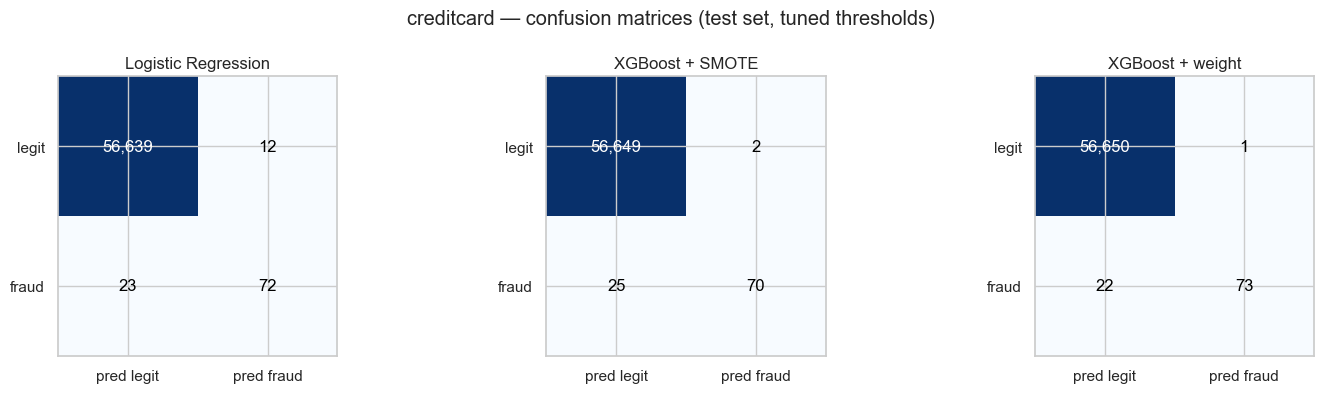

In [15]:
cc_cv_rows = []
for label, pipe in [('Logistic Regression + SMOTE', cc_lr),
                    ('XGBoost + SMOTE', cc_xgb),
                    ('XGBoost + scale_pos_weight', cc_xgb_w)]:
    frame = ev.cross_validate_model(pipe, Xc_train, yc_train, cv=CV_FOLDS)
    cc_cv_rows.append(ev.cv_summary_row(frame, label))
cc_cv = pd.DataFrame(cc_cv_rows)
print('creditcard — 5-fold CV on the training half (mean ± std):')
display(cc_cv)
ev.plot_pr_curves(
    {'Logistic Regression + SMOTE': (yc_test.to_numpy(), cc_lr_scores),
     'XGBoost + SMOTE': (yc_test.to_numpy(), cc_xgb_scores),
     'XGBoost + scale_pos_weight': (yc_test.to_numpy(), cc_xgb_w_scores)},
    'Precision-Recall — creditcard (test set)',
    FIG / 'creditcard_pr_curves_nb.png')
plt.show()
ev.plot_confusion_matrices(
    {'Logistic Regression': ev.confusion_frame(yc_test, cc_lr_scores, cc_lr_thr),
     'XGBoost + SMOTE': ev.confusion_frame(yc_test, cc_xgb_scores, cc_xgb_thr),
     'XGBoost + weight': ev.confusion_frame(yc_test, cc_xgb_w_scores, cc_xgb_w_thr)},
    'creditcard — confusion matrices (test set, tuned thresholds)',
    FIG / 'creditcard_confusion_nb.png')
plt.show()

## 8. Model selection

The two datasets are scored side by side below. Selection rule: take the highest **AUC-PR**, then break ties on **interpretability** and **cost of the residual errors** (a false negative is a realised loss; a false positive is a blocked customer).

In [16]:
combined = pd.concat([
    fraud_test.assign(dataset='Fraud_Data'),
    cc_test.assign(dataset='creditcard'),
])[['dataset', 'model', 'auc_pr', 'f1', 'precision', 'recall',
    'roc_auc', 'threshold', 'tp', 'fp', 'fn', 'tn']]
display(combined.round(4).set_index(['dataset', 'model']))
print('\n5-fold CV, Fraud_Data:'); display(fraud_cv)
print('5-fold CV, creditcard:'); display(cc_cv)

auc_pr      f1  precision  recall  \
dataset    model                                                            
Fraud_Data XGBoost + scale_pos_weight   0.7141  0.6900     0.9993  0.5269   
           XGBoost + SMOTE              0.7118  0.6891     0.9811  0.5311   
           Logistic Regression + SMOTE  0.6750  0.6677     0.9061  0.5286   
creditcard XGBoost + scale_pos_weight   0.8224  0.8639     0.9865  0.7684   
           XGBoost + SMOTE              0.8190  0.8383     0.9722  0.7368   
           Logistic Regression + SMOTE  0.6687  0.8045     0.8571  0.7579   

                                        roc_auc  threshold    tp   fp    fn  \
dataset    model                                                              
Fraud_Data XGBoost + scale_pos_weight    0.8387     0.8956  1491    1  1339   
           XGBoost + SMOTE               0.8391     0.4526  1503   29  1327   
           Logistic Regression + SMOTE   0.8389     0.8058  1496  155  1334   
creditcard XGBoost + scale_pos_weight    0.9785     0.8510    73    1    22   
           XGBoost + SMOTE               0.9709     0.9607    70    2    25   
           Logistic Regression + SMOTE   0.9625     1.0000    72   12    23   

                                           tn  
dataset    model                               
Fraud_Data XGBoost + scale_pos_weight   27392  
           XGBoost + SMOTE              27364  
           Logistic Regression + SMOTE  27238  
creditcard XGBoost + scale_pos_weight   56650  
           XGBoost + SMOTE              56649  
           Logistic Regression + SMOTE  56639


5-fold CV, Fraud_Data:


,model,auc_pr,f1,precision,recall,roc_auc
0,Logistic Regression + SMOTE,0.6823 ± 0.0073,0.6247 ± 0.0027,0.5870 ± 0.0065,0.6676 ± 0.0049,0.8437 ± 0.0064
1,XGBoost + SMOTE,0.7212 ± 0.0061,0.7009 ± 0.0061,0.9950 ± 0.0014,0.5410 ± 0.0071,0.8452 ± 0.0034
2,XGBoost + scale_pos_weight,0.7226 ± 0.0059,0.6189 ± 0.0034,0.5460 ± 0.0034,0.7142 ± 0.0059,0.8463 ± 0.0041


5-fold CV, creditcard:


,model,auc_pr,f1,precision,recall,roc_auc
0,Logistic Regression + SMOTE,0.7529 ± 0.0262,0.1039 ± 0.0097,0.0551 ± 0.0055,0.9073 ± 0.0337,0.9809 ± 0.0082
1,XGBoost + SMOTE,0.8486 ± 0.0314,0.8162 ± 0.0249,0.8151 ± 0.0273,0.8200 ± 0.0510,0.9780 ± 0.0053
2,XGBoost + scale_pos_weight,0.8531 ± 0.0271,0.8640 ± 0.0260,0.9092 ± 0.0369,0.8254 ± 0.0453,0.9820 ± 0.0057


In [17]:
# Persist the selected model per dataset (pipeline + its threshold).
config.ensure_dirs()
best_fraud = max([(xgb_metrics['auc_pr'], 'xgb_smote', xgb, xgb_thr),
                  (xgb_w_metrics['auc_pr'], 'xgb_weighted', xgb_w, xgb_w_thr),
                  (lr_metrics['auc_pr'], 'logreg_smote', lr, lr_thr)])
best_cc = max([(cc_xgb_metrics['auc_pr'], 'xgb_smote', cc_xgb, cc_xgb_thr),
               (cc_xgb_w_metrics['auc_pr'], 'xgb_weighted', cc_xgb_w, cc_xgb_w_thr),
               (cc_lr_metrics['auc_pr'], 'logreg_smote', cc_lr, cc_lr_thr)])
for dataset, (score, key, pipe, thr) in [('fraud', best_fraud), ('creditcard', best_cc)]:
    out = config.MODELS_DIR / f'{dataset}_selected.joblib'
    joblib.dump({'pipeline': pipe, 'threshold': thr, 'model_key': key}, out)
    print(f'{dataset}: selected {key} (AUC-PR {score:.4f}) -> {out.name}')

fraud: selected xgb_weighted (AUC-PR 0.7141) -> fraud_selected.joblib
creditcard: selected xgb_weighted (AUC-PR 0.8224) -> creditcard_selected.joblib


## 9. Summary

- **Data preparation** — stratified 80/20 split on both datasets; features and target separated (`class` / `Class`); all scaling, encoding and resampling confined to pipeline steps refit per fold.
- **Baseline** — Logistic Regression, evaluated on AUC-PR, F1 and the confusion matrix. Cheap, stable, and its coefficients are auditable.
- **Ensemble** — XGBoost with a grid search over `n_estimators`, `max_depth` and `learning_rate`, plus a `scale_pos_weight` variant to test the imbalance strategy itself.
- **Cross-validation** — 5-fold stratified, reported as mean ± std; the small std confirms the ranking is not a split artefact.
- **Thresholds** — chosen on out-of-fold training scores, because SMOTE decalibrates the default 0.50 cut-off.
- **Selection & justification** — see [`reports/task2-report.md`](../reports/task2-report.md).

Task 3 explains the selected model with SHAP: [`shap-explainability.ipynb`](shap-explainability.ipynb).